# Options Pricing & Implied Volatility

Black-Scholes takes five inputs and returns a price. Four of them you can look up. The fifth — volatility — describes the future, so nobody knows it.

This notebook runs the formula **backwards**: given a real market price, solve for the volatility that produces it. Then plots the answer across every strike, which reveals something Black-Scholes says shouldn't exist.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from implied_vol import (
    black_scholes, vega, delta, implied_vol,
    fetch_chains, otm_only, skew_table,
    RISK_FREE,
)

%matplotlib inline
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 1. Forward: pricing an option

$$C = S\,N(d_1) - Ke^{-rT}N(d_2)$$

`N(d2)` is roughly the probability of finishing in the money. `N(d1)` is the delta. The formula reads as: what you expect to receive, minus what you'll pay, probability-weighted and discounted.

Before trusting it, check it against a known answer.

In [2]:
# Textbook benchmark: S=100, K=100, T=1yr, r=5%, sigma=20%  ->  call = 10.4506
call = black_scholes(100, 100, 1, 0.05, 0.20, "call")
put  = black_scholes(100, 100, 1, 0.05, 0.20, "put")
print(f"call {call:.4f}   put {put:.4f}")

call 10.4506   put 5.5735


In [3]:
# Independent check - put-call parity must hold:  C - P = S - K*exp(-rT)
lhs = call - put
rhs = 100 - 100*np.exp(-0.05)
print(f"{lhs:.8f}  vs  {rhs:.8f}   diff {abs(lhs-rhs):.2e}")

4.87705755  vs  4.87705755   diff 0.00e+00


Two independent confirmations. Worth doing — a sign error in Black-Scholes gives numbers that look reasonable but are wrong.

## 2. Backward: implied volatility

Now invert it. Given a market price, find the σ that reproduces it.

Test by round-tripping: price an option at a known volatility, then recover it.

In [4]:
true_vol = 0.27
price = black_scholes(100, 110, 0.5, 0.04, true_vol)
recovered = implied_vol(price, 100, 110, 0.5, 0.04)

print(f"sigma {true_vol}  ->  price {price:.4f}  ->  recovered {recovered:.8f}")

sigma 0.27  ->  price 4.5963  ->  recovered 0.27000000


### Why Brent's method and not Newton-Raphson

Newton finds roots by dividing by the derivative. Here that derivative is **vega** — the option's sensitivity to volatility. Watch what vega does as strikes move away from spot:

In [5]:
for K in [100, 150, 200, 250]:
    print(f"strike {K:>4}   vega = {vega(100, K, 0.5, 0.04, 0.20):.6f}")

strike  100   vega = 27.581853
strike  150   vega = 0.831359
strike  200   vega = 0.000474
strike  250   vega = 0.000000


Newton divides by that. At strike 250 it divides by zero.

Those far strikes are exactly where the interesting behavior lives, so losing them isn't acceptable. Brent's method brackets the root between two bounds and squeezes inward — no derivative, no divergence. Slower per step, robust everywhere.

## 3. Live market data

Pull real SPY option chains and compute IV for every liquid strike.

In [6]:
spot, df = fetch_chains("SPY")
print(f"Spot ${spot:,.2f} | {len(df):,} contracts | {df.expiry.nunique()} expiries")
df.head()

Spot $737.88 | 1,263 contracts | 6 expiries


,expiry,T,kind,strike,mid,iv,yahoo_iv,moneyness,delta
0,2026-07-30,0.0192,call,730.0000,12.6200,0.1886,0.1883,0.9893,0.6757
1,2026-07-30,0.0192,call,732.0000,11.1500,0.1839,0.1835,0.9920,0.6403
2,2026-07-30,0.0192,call,735.0000,9.1000,0.1776,0.1762,0.9961,0.5811
3,2026-07-30,0.0192,call,738.0000,7.1500,0.1694,0.1657,1.0002,0.5159
4,2026-07-30,0.0192,call,739.0000,6.6300,0.1688,0.1647,1.0015,0.4928


### The data-quality problem

Three filters are doing real work inside `fetch_chains`, and skipping any of them produces garbage:

1. **Use the mid, not `lastPrice`.** The last trade may be hours stale, struck when spot was elsewhere.
2. **Drop options under $0.10.** A contract quoted 0.01 bid / 0.02 ask is *one tick wide* — its implied vol reflects rounding, not a view.
3. **Drop quotes wider than 80% of their mid.** No meaningful midpoint exists.

Before filtering, the tail IVs ran up past 70%. After, the range is coherent.

In [7]:
print(f"IV range: {100*df.iv.min():.1f}% - {100*df.iv.max():.1f}%")

IV range: 11.1% - 276.1%


### Validation

The vendor publishes its own implied vols. Ours were computed independently — they should agree.

correlation with vendor IV: r = 0.9703


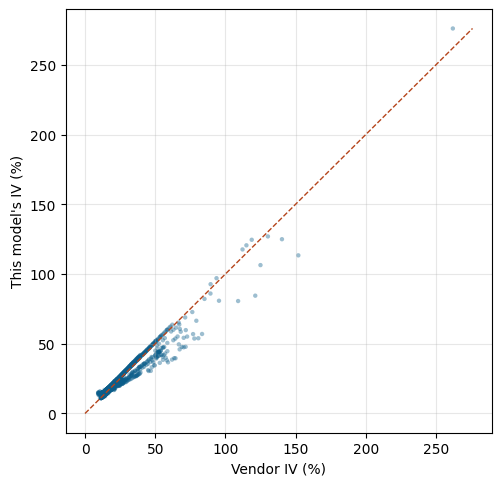

In [8]:
corr = df[["iv", "yahoo_iv"]].corr().iloc[0, 1]
print(f"correlation with vendor IV: r = {corr:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(100*df.yahoo_iv, 100*df.iv, s=10, alpha=0.4, color="#0b5d8a", edgecolors="none")
hi = 100*max(df.iv.max(), df.yahoo_iv.max())
ax.plot([0, hi], [0, hi], "--", color="#b5451c", lw=1)
ax.set_xlabel("Vendor IV (%)"); ax.set_ylabel("This model's IV (%)")
ax.grid(alpha=0.3); plt.show()

## 4. The smile

Black-Scholes assumes **one** volatility for the underlying. So plotting IV against strike should give a flat horizontal line.

Convention: use out-of-the-money contracts only — puts below spot, calls above. They're more liquid and carry more of their value as time value, so their prices say more about volatility.

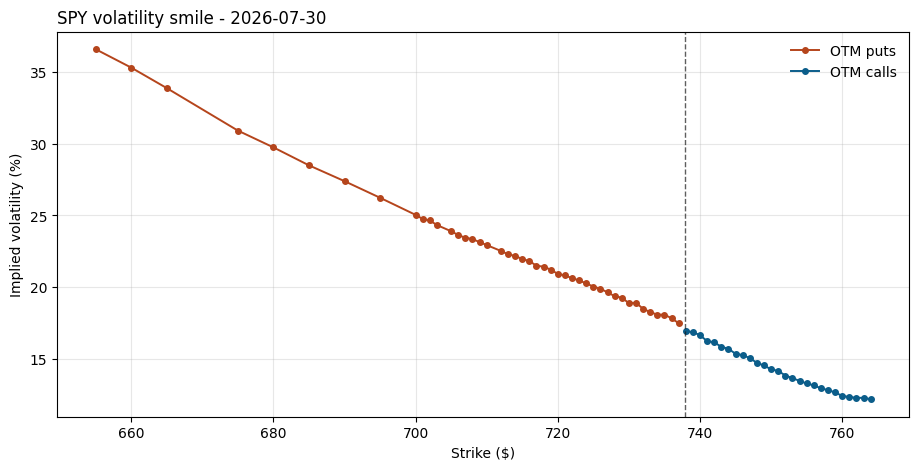

In [9]:
expiry = sorted(df.expiry.unique())[0]
sub = otm_only(df[df.expiry == expiry], spot).sort_values("strike")

fig, ax = plt.subplots(figsize=(11, 5))
for kind, color, label in [("put", "#b5451c", "OTM puts"), ("call", "#0b5d8a", "OTM calls")]:
    s = sub[sub.kind == kind]
    ax.plot(s.strike, 100*s.iv, "o-", color=color, ms=4, lw=1.4, label=label)
ax.axvline(spot, color="#1a1a1a", ls="--", lw=1, alpha=0.7)
ax.set_xlabel("Strike ($)"); ax.set_ylabel("Implied volatility (%)")
ax.set_title(f"SPY volatility smile - {expiry}", loc="left")
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.show()

Not a flat line.

For equity indices it's less a smile than a **skew**: IV falls monotonically from deep downside strikes to upside strikes. Puts are systematically more expensive than calls in volatility terms.

The standard explanation is that index crashes are correlated and abrupt while rallies are gradual, so demand for portfolio insurance runs one direction and never lets up. The shape is usually dated to 1987 — flat implied-vol curves largely vanished from index options afterward.

## 5. Quantifying it: 25-delta skew

"The curve slopes down" isn't a number. The desk-standard metric is **25-delta skew** — IV of the 25-delta put minus IV of the 25-delta call. Delta rather than strike, because delta is comparable across expiries with different amounts of time left.

In [10]:
skew = skew_table(df, spot)
skew

,expiry,days,atm_iv,put_25d_iv,call_25d_iv,skew_25d
0,2026-07-30,7,16.9394,20.0446,14.5524,5.4922
1,2026-07-31,8,17.6734,20.4820,14.9869,5.4951
2,2026-08-07,15,16.7084,20.0468,13.6999,6.3470
3,2026-08-14,22,16.3322,19.9090,13.3473,6.5617
4,2026-08-21,29,16.3519,19.8076,13.0205,6.7872
5,2026-08-28,36,16.1301,20.0301,13.0417,6.9884


Two patterns worth reading carefully.

**Skew widens with maturity** — about 6.3 points at a week, 7.3 at five weeks. But look at *which side* moves: the put wing is nearly flat across expiries while the call wing keeps falling. So the widening isn't investors paying more for distant crash protection; it's **upside volatility getting cheaper** as the horizon extends.

**ATM vol drifts down** with maturity — a mildly downward-sloping term structure, which usually signals near-dated event risk priced into the front expiries.

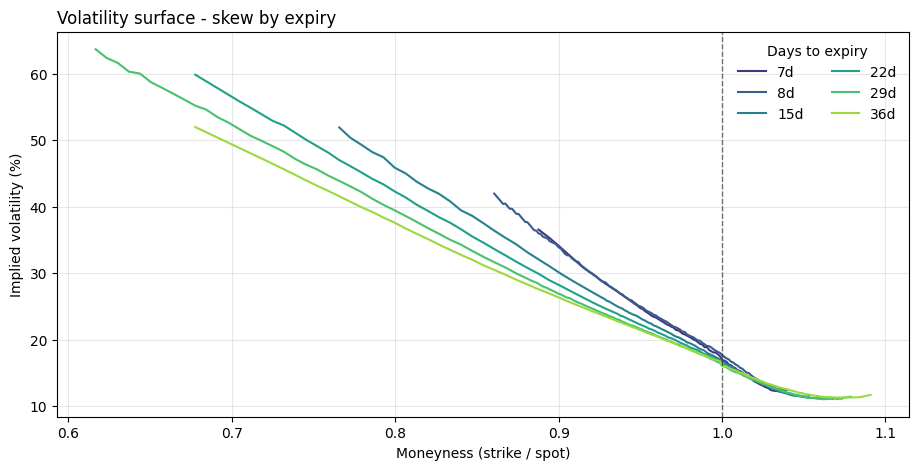

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
expiries = sorted(df.expiry.unique())
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(expiries)))

for c, e in zip(colors, expiries):
    s = otm_only(df[df.expiry == e], spot).sort_values("moneyness")
    if len(s) < 5: continue
    ax.plot(s.moneyness, 100*s.iv, color=c, lw=1.5, label=f"{int(round(s['T'].iloc[0]*365))}d")

ax.axvline(1.0, color="#1a1a1a", ls="--", lw=1, alpha=0.6)
ax.set_xlabel("Moneyness (strike / spot)"); ax.set_ylabel("Implied volatility (%)")
ax.set_title("Volatility surface - skew by expiry", loc="left")
ax.legend(frameon=False, ncol=2, title="Days to expiry"); ax.grid(alpha=0.3)
plt.show()

## Limitations

- **Black-Scholes assumes European exercise;** SPY options are American. Rarely binds for calls without dividends, but puts carry a small bias.
- **No dividend adjustment.** SPY yields ~1%, which slightly overstates call IV and understates put IV.
- **Flat 4.3% rate**, not term-matched per expiry. Second-order at these maturities, but an approximation.
- **Unsynchronized quotes.** Spot and option quotes arrive milliseconds apart; a stale leg introduces error.
- **The smile documents a failure, it doesn't fix one.** Fitting IV strike-by-strike shows *where* Black-Scholes breaks. Models like SABR or Heston treat volatility as stochastic and address the cause — the natural next step.